<a href="https://colab.research.google.com/github/ramu1255/g.p.s/blob/main/debugging_prompt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# Tower coordinates
tower1 = (0, 0)
tower2 = (10, 0)
tower3 = (4, 8)

# Benchmark phone location
# Used ONLY to generate realistic test distances
# Solver does NOT use this value.
test_phone = (5, 3)

# Distance formula
d1 = np.sqrt((test_phone[0] - tower1[0])**2 +
             (test_phone[1] - tower1[1])**2)

d2 = np.sqrt((test_phone[0] - tower2[0])**2 +
             (test_phone[1] - tower2[1])**2)

d3 = np.sqrt((test_phone[0] - tower3[0])**2 +
             (test_phone[1] - tower3[1])**2)

print("Tower 1:", tower1, "Distance:", d1)
print("Tower 2:", tower2, "Distance:", d2)
print("Tower 3:", tower3, "Distance:", d3)

Tower 1: (0, 0) Distance: 5.830951894845301
Tower 2: (10, 0) Distance: 5.830951894845301
Tower 3: (4, 8) Distance: 5.0990195135927845


In [3]:
# Unknown coordinates
x, y = sp.symbols('x y')

x1, y1 = tower1
x2, y2 = tower2
x3, y3 = tower3

# --------------------------------------------------
# THREE NONLINEAR CIRCLE EQUATIONS
# --------------------------------------------------

eq1 = (x - x1)**2 + (y - y1)**2 - d1**2
eq2 = (x - x2)**2 + (y - y2)**2 - d2**2
eq3 = (x - x3)**2 + (y - y3)**2 - d3**2

print("CIRCLE EQUATIONS")
print("=" * 50)

sp.pprint(sp.Eq(eq1, 0))
sp.pprint(sp.Eq(eq2, 0))
sp.pprint(sp.Eq(eq3, 0))


# --------------------------------------------------
# SUBTRACT EQUATIONS
# --------------------------------------------------

linear1 = sp.expand(eq2 - eq1)
linear2 = sp.expand(eq3 - eq1)

print("\nLINEAR EQUATIONS")
print("=" * 50)

sp.pprint(sp.Eq(linear1, 0))
sp.pprint(sp.Eq(linear2, 0))


# --------------------------------------------------
# CONVERT TO:
#
# A*x + B*y = C
# D*x + E*y = F
# --------------------------------------------------

poly1 = sp.Poly(linear1, x, y)
poly2 = sp.Poly(linear2, x, y)

A = float(poly1.coeff_monomial(x))
B = float(poly1.coeff_monomial(y))
C = float(-poly1.coeff_monomial(1))

D = float(poly2.coeff_monomial(x))
E = float(poly2.coeff_monomial(y))
F = float(-poly2.coeff_monomial(1))

print("\nSYSTEM OF LINEAR EQUATIONS")
print("=" * 50)

print(f"{A:.6f}x + {B:.6f}y = {C:.6f}")
print(f"{D:.6f}x + {E:.6f}y = {F:.6f}")


# --------------------------------------------------
# MATRIX SOLUTION
# --------------------------------------------------

M = np.array([
    [A, B],
    [D, E]
], dtype=float)

B_vector = np.array([
    C,
    F
], dtype=float)

# Check unique solution
if abs(np.linalg.det(M)) < 1e-10:
    raise ValueError("The tower arrangement does not give a unique solution.")

solution = np.linalg.solve(M, B_vector)

calculated_x = solution[0]
calculated_y = solution[1]

print("\nCALCULATED LOCATION")
print("=" * 50)

print(f"x = {calculated_x:.6f}")
print(f"y = {calculated_y:.6f}")

CIRCLE EQUATIONS
 2    2           
x  + y  - 34.0 = 0
 2           2           
y  + (x - 10)  - 34.0 = 0
       2          2           
(x - 4)  + (y - 8)  - 26.0 = 0

LINEAR EQUATIONS
100 - 20⋅x = 0
-8⋅x - 16⋅y + 88.0 = 0

SYSTEM OF LINEAR EQUATIONS
-20.000000x + 0.000000y = -100.000000
-8.000000x + -16.000000y = -88.000000

CALCULATED LOCATION
x = 5.000000
y = 3.000000


In [4]:
# Verify calculated location using original distance equations

phone = np.array([calculated_x, calculated_y])

T1 = np.array(tower1)
T2 = np.array(tower2)
T3 = np.array(tower3)

check1 = np.linalg.norm(phone - T1)
check2 = np.linalg.norm(phone - T2)
check3 = np.linalg.norm(phone - T3)

print("VERIFICATION")
print("=" * 60)

print(f"Tower 1: Input = {d1:.6f}, Calculated = {check1:.6f}")
print(f"Tower 2: Input = {d2:.6f}, Calculated = {check2:.6f}")
print(f"Tower 3: Input = {d3:.6f}, Calculated = {check3:.6f}")

print("\nCoordinate verification:")
print(f"Expected X = 5.000000")
print(f"Calculated X = {calculated_x:.6f}")

print(f"\nExpected Y = 3.000000")
print(f"Calculated Y = {calculated_y:.6f}")

if np.allclose([calculated_x, calculated_y], [5, 3], atol=1e-6):
    print("\n✅ MATHEMATICAL RESULT IS CORRECT")
else:
    print("\n❌ RESULT NEEDS CHECKING")

VERIFICATION
Tower 1: Input = 5.830952, Calculated = 5.830952
Tower 2: Input = 5.830952, Calculated = 5.830952
Tower 3: Input = 5.099020, Calculated = 5.099020

Coordinate verification:
Expected X = 5.000000
Calculated X = 5.000000

Expected Y = 3.000000
Calculated Y = 3.000000

✅ MATHEMATICAL RESULT IS CORRECT


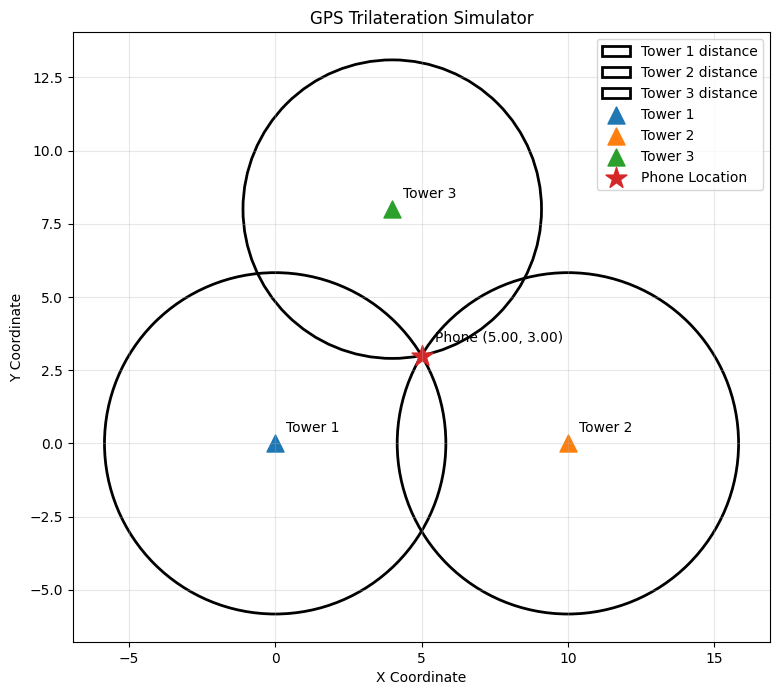

In [5]:
fig, ax = plt.subplots(figsize=(9, 8))

# Circles
ax.add_patch(Circle(T1, d1, fill=False, linewidth=2,
                    label="Tower 1 distance"))

ax.add_patch(Circle(T2, d2, fill=False, linewidth=2,
                    label="Tower 2 distance"))

ax.add_patch(Circle(T3, d3, fill=False, linewidth=2,
                    label="Tower 3 distance"))

# Towers
ax.scatter(*T1, s=150, marker="^", label="Tower 1")
ax.scatter(*T2, s=150, marker="^", label="Tower 2")
ax.scatter(*T3, s=150, marker="^", label="Tower 3")

# Calculated phone
ax.scatter(
    calculated_x,
    calculated_y,
    s=250,
    marker="*",
    label="Phone Location"
)

# Labels
ax.annotate("Tower 1", T1, xytext=(8, 8),
            textcoords="offset points")

ax.annotate("Tower 2", T2, xytext=(8, 8),
            textcoords="offset points")

ax.annotate("Tower 3", T3, xytext=(8, 8),
            textcoords="offset points")

ax.annotate(
    f"Phone ({calculated_x:.2f}, {calculated_y:.2f})",
    phone,
    xytext=(10, 10),
    textcoords="offset points"
)

ax.set_xlabel("X Coordinate")
ax.set_ylabel("Y Coordinate")
ax.set_title("GPS Trilateration Simulator")

ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()